# Which countries have better or worse life expectancy than their income predicts and does climate vulnerability help explain that gap?

### Data Collection

In [193]:
# Import packages

import wbgapi as wb
import pandas as pd 
import numpy as np 
import matplotlib as plt
import seaborn as sb 
import plotly as pt
import statsmodels as sm

In [91]:
# View all attributes in WBD

dir(wb)

['APIError',
 'APIResponseError',
 'Coder',
 'Featureset',
 'Metadata',
 'MetadataCollection',
 'Series',
 'URLError',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_concept_mrv_cache',
 '_queryAPI',
 '_refetch_url',
 '_responseHeader',
 '_responseObjects',
 'abbreviate',
 'api_maxlen',
 'data',
 'db',
 'economy',
 'economy_coder',
 'economy_metadata',
 'endpoint',
 'fetch',
 'get',
 'get_options',
 'htmlTable',
 'income',
 'lang',
 'lending',
 'metadata',
 'pd',
 'per_page',
 'proxies',
 'queryParam',
 're',
 'reduce',
 'refetch',
 'region',
 'requests',
 'search',
 'search2',
 'series',
 'series_metadata',
 'source',
 'tabulate',
 'time',
 'topic',
 'urllib',
 'utils',
 'warnings']

In [92]:
# Find code for dataset
wb.source.info()

id,name,code,concepts,lastupdated
1,Doing Business,DBS,3,2021-08-18
2,World Development Indicators,WDI,3,2026-07-13
3,Worldwide Governance Indicators,WGI,3,2026-09-25
5,Subnational Malnutrition Database,SNM,3,2016-03-21
6,International Debt Statistics,IDS,4,2025-12-03
11,Africa Development Indicators,ADI,3,2013-02-22
12,Education Statistics,EDS,3,2024-06-25
13,Enterprise Surveys,ESY,3,2022-03-25
14,Gender Statistics,GDS,3,2026-07-22
15,Global Economic Monitor,GEM,3,2026-09-08


In [93]:
# Accessing id for Life Expectancy indicator
wb.series.info(q = 'life expectancy', db = 2)

id,value
SP.DYN.LE00.FE.IN,"Life expectancy at birth, female (years)"
SP.DYN.LE00.IN,"Life expectancy at birth, total (years)"
SP.DYN.LE00.MA.IN,"Life expectancy at birth, male (years)"
,3 elements


In [94]:
# Accessing id for GDP PPP indicator
wb.series.info(q = 'GDP per capita', db = 2)

id,value
NY.GDP.PCAP.CD,GDP per capita (current US$)
NY.GDP.PCAP.CN,GDP per capita (current LCU)
NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$)
NY.GDP.PCAP.KD.ZG,GDP per capita growth (annual %)
NY.GDP.PCAP.KN,GDP per capita (constant LCU)
NY.GDP.PCAP.PP.CD,"GDP per capita, PPP (current international $)"
NY.GDP.PCAP.PP.KD,"GDP per capita, PPP (constant 2021 international $)"
,7 elements


In [95]:
# Accessing id for climate indicator

wb.series.info(q='CO2', db=2)

id,value
EN.GHG.CO2.AG.MT.CE.AR5,Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)
EN.GHG.CO2.BU.MT.CE.AR5,Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)
EN.GHG.CO2.FE.MT.CE.AR5,Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)
EN.GHG.CO2.IC.MT.CE.AR5,Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)
EN.GHG.CO2.IP.MT.CE.AR5,Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
EN.GHG.CO2.LU.DF.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Deforestation (Mt CO2e)
EN.GHG.CO2.LU.FL.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Forest Land (Mt CO2e)
EN.GHG.CO2.LU.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)
EN.GHG.CO2.LU.OL.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Other Land (Mt CO2e)
EN.GHG.CO2.LU.OS.MT.CE.AR5,Carbon dioxide (CO2) net fluxes from LULUCF - Organic Soil (Mt CO2e)


In [96]:
# Accessing id for climate indicator
wb.series.info(q='water', db=2)

id,value
ER.GDP.FWTL.M3.KD,"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)"
ER.H2O.FWAG.ZS,"Annual freshwater withdrawals, agriculture (% of total freshwater withdrawal)"
ER.H2O.FWDM.ZS,"Annual freshwater withdrawals, domestic (% of total freshwater withdrawal)"
ER.H2O.FWIN.ZS,"Annual freshwater withdrawals, industry (% of total freshwater withdrawal)"
ER.H2O.FWST.ZS,Level of water stress: freshwater withdrawal as a proportion of available freshwater resources
ER.H2O.FWTL.K3,"Annual freshwater withdrawals, total (billion cubic meters)"
ER.H2O.FWTL.ZS,"Annual freshwater withdrawals, total (% of internal resources)"
ER.H2O.INTR.K3,"Renewable internal freshwater resources, total (billion cubic meters)"
ER.H2O.INTR.PC,Renewable internal freshwater resources per capita (cubic meters)
IE.PPI.WATR.CD,Investment in water and sanitation with private participation (current US$)


In [97]:
# Accessing id for climate indicator
wb.series.info(q='disaster', db=2)

id,value
EN.CLC.DRSK.XQ,Disaster risk reduction progress score (1-5 scale; 5=best)
VC.IDP.NWDS,"Internally displaced persons, new displacement associated with disasters (number of cases)"
,2 elements


In [98]:
help(wb.data.DataFrame)

Help on function DataFrame in module wbgapi.data:

DataFrame(
    series,
    economy='all',
    time='all',
    index=None,
    columns=None,
    mrv=None,
    mrnev=None,
    skipBlanks=False,
    labels=False,
    skipAggs=False,
    numericTimeKeys=False,
    timeColumns=False,
    params={},
    db=None,
    **dimensions
)
    Retrieve a 2-dimensional pandas dataframe.

    Arguments:
        series:             a series identifier or list-like, e.g., SP.POP.TOTL

        economy:            an economy identifier or list-like, e.g., 'BRA' or ['USA', 'CAN', 'MEX']

        time:               a time identifier or list-like, e.g., 'YR2015' or range(2010,2020).
                            Both element keys and values are acceptable

        index:              name or list of dimensions for the DataFrame's index, e.g., 'economy'. If None then the function
                            will define the index based on your request. Note: to get a dataframe with no index
                  

In [99]:
# Checking climate variable
climate_df = wb.data.DataFrame('EN.CLC.DRSK.XQ', time = range(2000, 2026), skipBlanks = True)
climate_df

,YR2011
economy,
ARG,3.25
ARM,3.00
ATG,2.75
AUS,4.00
BDI,3.25
...,...
VEN,2.75
VUT,2.00
WSM,3.50


In [100]:
# Checking the data
climate_df.shape


(83, 1)

In [101]:
climate_df.columns
# note for when writing: the disasters indicator cannot be used 
# for climate vulnerabilty because it has only recorded data for 2011 and not from
# 2000 - 2026 and it is missing data of other countries

Index(['YR2011'], dtype='str')

In [102]:
# Accessing id for climate indicator
a = wb.series.info(q='temperature', db=2)
b = wb.series.info(q='vulnerability', db=2)
c = wb.series.info(q='flood', db=2)
d = wb.series.info(q='drought', db=2)
print(a)
print(b)
print(c)
print(d)

id              value
--------------  ---------------------------------------------------------------------------
EN.CLC.MDAT.ZS  Droughts, floods, extreme temperatures (% of population, average 1990-2009)
                1 elements

id              value
--------------  ---------------------------------------------------------------------------
EN.CLC.MDAT.ZS  Droughts, floods, extreme temperatures (% of population, average 1990-2009)
                1 elements
id              value
--------------  ---------------------------------------------------------------------------
EN.CLC.MDAT.ZS  Droughts, floods, extreme temperatures (% of population, average 1990-2009)
                1 elements


In [103]:
# Checking drought

drought_df = wb.data.DataFrame('EN.CLC.MDAT.ZS', time = range(2000, 2026), skipBlanks = True)
drought_df.shape

(168, 1)

In [104]:
drought_df.columns
# note for write up: drought indicator only shows 2009 and 168 countries

Index(['YR2009'], dtype='str')

In [105]:
# Check for other possible climate indicators with db 87
wb.series.info(q = 'climate', db = 87)

In [106]:
wb.series.info(q = 'vulnerability', db = 87)


In [107]:
wb.series.info(q = 'risk', db = 87)


id,value
CC.INCP.ALRS,"Annual investment needs for coastal protection, by risk strategy (% of GDP) - low risk tolerance"
CC.INCP.KRGC,"Annual investment needs for coastal protection, by risk strategy (% of GDP) - constant relative flood risk"
CC.INCP.SPMC,"Annual investment needs for coastal protection, by risk strategy (% of GDP) - optimal protection"
CC.RISK.AST.ZS,Risk to asset (average annual losses as % of GDP)
CC.RISK.WELL.ZS,Risk to wellbeing (average annual losses as % of GDP)
,5 elements


In [108]:
wb.series.info(q = 'exposure', db = 87)

id,value
CC.ADPO.MAEX.AA,"Additional population exposed to annual coastal floods due to sea level rise, as a share of actual population (%) - Min. exposure, 2100"
CC.ADPO.MAEX.BB,"Additional population exposed to annual coastal floods due to sea level rise, as a share of actual population (%) - Max exposure, 2100"
CC.ADPO.MIEX.AA,"Additional population exposed to annual coastal floods due to sea level rise, as a share of actual population (%) - Min. exposure, 2050"
CC.ADPO.MIEX.BB,"Additional population exposed to annual coastal floods due to sea level rise, as a share of actual population (%) - Max exposure, 2050"
,4 elements


In [109]:
wb.series.info(q = 'temperature', db = 87)

id,value
CC.AVPB.TPOP.TE,"Additional people below $4 as % of total population by impact, by 2030 - Temperature"
CC.CHIC.BTFP.TE,"Change in income (%) for bottom 40% of the population by impact, by 2030 - Temperature (original)"
,2 elements


In [110]:
# Check for other possible climate indicators with db 75
wb.series.info(q = 'climate', db = 75)

In [111]:
wb.series.info(q = 'vulnerability', db = 75)

In [112]:
wb.series.info(q = 'risk', db = 75)

In [113]:
wb.series.info(q = 'exposure', db = 75)

id,value
EN.ATM.PM25.MC.M3,"PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)"
,1 elements


In [114]:
wb.series.info(q = 'temperature', db = 75)

id,value
EN.LND.LTMP.DC,Land Surface Temperature
,1 elements


In [115]:
# Checking db 87 
risk_df = wb.data.DataFrame('CC.RISK.WELL.ZS', time=range(2000,2026), skipBlanks = True, db=87 )
risk_df.shape

(126, 1)

In [116]:
risk_df.columns

Index(['YR2016'], dtype='str')

In [117]:
risk_df.head()

,YR2016
economy,
AGO,0.473847
ALB,1.403118
ARG,0.697381
ARM,0.983649
AUS,0.258307


In [118]:
risk_df.dtypes

YR2016    float64
dtype: object

In [119]:
risk_df.index

Index(['AGO', 'ALB', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN',
       ...
       'TZA', 'UGA', 'UKR', 'URY', 'USA', 'VNM', 'YEM', 'ZAF', 'ZMB', 'ZWE'],
      dtype='str', name='economy', length=126)

In [120]:
risk_df.isnull().sum()

YR2016    0
dtype: int64

In [121]:
risk_df.duplicated().sum()

np.int64(0)

In [122]:
# since risk_data is the most recent year I can
#  find around climate vulnerability this will be the dataset used in 
# this project. The question will be changed.

In [123]:
# The new dataset with 2 selected indicators
df = wb.data.DataFrame(['SP.DYN.LE00.IN', 'NY.GDP.PCAP.PP.CD'], time=range(2000, 2026), skipBlanks=True, columns='series')

In [124]:
# Data inspection
df.shape

(6832, 2)

In [125]:
df.dtypes

NY.GDP.PCAP.PP.CD    float64
SP.DYN.LE00.IN       float64
dtype: object

In [126]:
df.columns

Index(['NY.GDP.PCAP.PP.CD', 'SP.DYN.LE00.IN'], dtype='str')

In [127]:
df.index

MultiIndex([('ABW', 'YR2000'),
            ('ABW', 'YR2001'),
            ('ABW', 'YR2002'),
            ('ABW', 'YR2003'),
            ('ABW', 'YR2004'),
            ('ABW', 'YR2005'),
            ('ABW', 'YR2006'),
            ('ABW', 'YR2007'),
            ('ABW', 'YR2008'),
            ('ABW', 'YR2009'),
            ...
            ('ZWE', 'YR2016'),
            ('ZWE', 'YR2017'),
            ('ZWE', 'YR2018'),
            ('ZWE', 'YR2019'),
            ('ZWE', 'YR2020'),
            ('ZWE', 'YR2021'),
            ('ZWE', 'YR2022'),
            ('ZWE', 'YR2023'),
            ('ZWE', 'YR2024'),
            ('ZWE', 'YR2025')],
           names=['economy', 'time'], length=6832)

In [128]:
df.head()

NY.GDP.PCAP.PP.CD  SP.DYN.LE00.IN
economy time                                     
ABW     YR2000       30245.706973          72.939
        YR2001       31920.239073          73.044
        YR2002       31888.508736          73.135
        YR2003       32507.084315          73.236
        YR2004       35059.273098          73.223

In [129]:
df.tail()

NY.GDP.PCAP.PP.CD  SP.DYN.LE00.IN
economy time                                     
ZWE     YR2021        4827.109602          60.135
        YR2022        5395.024529          62.360
        YR2023        5795.990470          62.775
        YR2024        5932.870220          63.064
        YR2025        6470.416132             NaN

In [130]:
df.isnull().sum()

NY.GDP.PCAP.PP.CD    480
SP.DYN.LE00.IN       232
dtype: int64

In [131]:
df.duplicated().sum()

np.int64(59)

In [132]:
wb.economy.info()

id,value,region,incomeLevel
ABW,Aruba,LCN,HIC
AFE,Africa Eastern and Southern,,
AFG,Afghanistan,MEA,LIC
AFW,Africa Western and Central,,
AGO,Angola,SSF,LMC
ALB,Albania,ECS,UMC
AND,Andorra,ECS,HIC
ARB,Arab World,,
ARE,United Arab Emirates,MEA,HIC
ARG,Argentina,LCN,UMC


### Data Cleaning

In [149]:
# Economy reference table as a DataFrame
economies = wb.economy.DataFrame()

In [150]:
economies.head()

,name,aggregate,longitude,latitude,region,adminregion,lendingType,incomeLevel,capitalCity
id,,,,,,,,,
ABW,Aruba,False,-70.0167,12.51670,LCN,,LNX,HIC,Oranjestad
AFE,Africa Eastern and Southern,True,NaN,NaN,,,,,
AFG,Afghanistan,False,69.1761,34.52280,MEA,MNA,IDX,LIC,Kabul
AFW,Africa Western and Central,True,NaN,NaN,,,,,
AGO,Angola,False,13.2420,-8.81155,SSF,SSA,IBD,LMC,Luanda


In [151]:
economies.shape

(265, 9)

In [152]:
# Keep real countries (aggregates have blank region)
real_countries = economies[economies['region'].notna()]
real_countries.shape

(265, 9)

In [153]:
# Filter df and risk_df to contain only real countries
df_clean = df[df.index.get_level_values('economy').isin(real_countries.index)]
risk_clean = risk_df[risk_df.index.isin(real_countries.index)]

In [161]:
df_clean.shape

(6832, 2)

In [162]:
risk_clean.shape

(126, 1)

In [163]:
economies['region'].head(10)


id
ABW    LCN
AFE       
AFG    MEA
AFW       
AGO    SSF
ALB    ECS
AND    ECS
ARB       
ARE    MEA
ARG    LCN
Name: region, dtype: str

In [164]:
economies['region'].unique()

<StringArray>
['LCN', '', 'MEA', 'SSF', 'ECS', 'EAS', 'SAS', 'NAC']
Length: 8, dtype: str

In [ ]:
# the empty strings have ' ' and not na
# original filter does nothing
# will change filter condition

In [165]:
# Keep real countries (aggregates have blank region)
real_countries = economies[economies['region'] != '']
real_countries.shape

(217, 9)

In [166]:
# Filter df and risk_df to contain only real countries
df_clean = df[df.index.get_level_values('economy').isin(real_countries.index)]
risk_clean = risk_df[risk_df.index.isin(real_countries.index)]

In [167]:
df_clean.shape

(5610, 2)

In [168]:
risk_clean.shape

(126, 1)

In [ ]:
# 217 countries x 26 years = 5,642
# 5,642 - 5,610 = 32 
# difference probably because of skipBlanks=True

In [169]:
# Fix year format
# reset index
df_clean = df_clean.reset_index()

# strip YR and convert to integer
df_clean['time'] = df_clean['time'].str.replace('YR', '').astype(int)


In [170]:
df_clean.head()

,economy,time,NY.GDP.PCAP.PP.CD,SP.DYN.LE00.IN
0,ABW,2000,30245.706973,72.939
1,ABW,2001,31920.239073,73.044
2,ABW,2002,31888.508736,73.135
3,ABW,2003,32507.084315,73.236
4,ABW,2004,35059.273098,73.223


In [171]:
df_clean.dtypes

economy                  str
time                   int64
NY.GDP.PCAP.PP.CD    float64
SP.DYN.LE00.IN       float64
dtype: object

In [172]:
# check for missing values
df_clean.isnull().sum()

economy                0
time                   0
NY.GDP.PCAP.PP.CD    480
SP.DYN.LE00.IN       185
dtype: int64

In [173]:
# which years have the most missing GDP values?
df_clean[df_clean['NY.GDP.PCAP.PP.CD'].isnull()]['time'].value_counts().sort_index()

time
2000    23
2001    23
2002    22
2003    22
2004    22
2005    22
2006    21
2007    20
2008    17
2009    16
2010    16
2011    16
2012    18
2013    17
2014    18
2015    18
2016    19
2017    18
2018    18
2019    18
2020    18
2021    18
2022    18
2023    20
2024    22
Name: count, dtype: int64

In [174]:
# which countries are missing GDP data. How many years are they missing?
df_clean[df_clean['NY.GDP.PCAP.PP.CD'].isnull()]['economy'].value_counts()

economy
ASM    25
CHI    25
CUB    25
GIB    25
GUM    25
IMN    25
LIE    25
MAF    25
MCO    25
MNP    25
NCL    25
PRK    25
PYF    25
VGB    25
SYR    19
SSD    17
DJI    13
ERI    13
VEN    13
YEM    11
SXM     9
FRO     8
XKX     8
TCA     7
CYM     6
VIR     4
GRL     1
SMR     1
Name: count, dtype: int64

In [ ]:
# some countries above are missing economic data 
# for all 25 years
# will drop these countries


In [175]:
# Countries with no usable data or too sparse to include (more than half)

drop_countries = ['ASM', 'CHI', 'CUB', 'GIB', 'GUM', 'IMN', 'LIE',
                   'MAF', 'MCO', 'MNP','NCL', 'PRK', 'PYF', 'VGB', 'SYR', 'SSD', 'DJI', 'ERI', 'VEN']

df_clean = df_clean[~df_clean['economy'].isin(drop_countries)]


In [176]:
df_clean.shape

(5134, 4)

In [177]:
df_clean.isnull().sum()

economy                0
time                   0
NY.GDP.PCAP.PP.CD     55
SP.DYN.LE00.IN       184
dtype: int64

In [178]:
# Check to see remaining null countries
df_clean[df_clean['NY.GDP.PCAP.PP.CD'].isnull()]['economy'].value_counts()

economy
YEM    11
SXM     9
FRO     8
XKX     8
TCA     7
CYM     6
VIR     4
GRL     1
SMR     1
Name: count, dtype: int64

In [179]:
# check remaining life expectancy nulls
df_clean[df_clean['SP.DYN.LE00.IN'].isnull()]['economy'].value_counts()

economy
AGO    1
ALB    1
AND    1
ARG    1
ARM    1
      ..
WSM    1
XKX    1
ZAF    1
ZMB    1
ZWE    1
Name: count, Length: 184, dtype: int64

In [180]:
# which year are the nulls concentrated
df_clean[df_clean['SP.DYN.LE00.IN'].isnull()]['time'].value_counts()

time
2025    184
Name: count, dtype: int64

In [ ]:
# no life expectancy data for the year 2025.

In [181]:
df_clean.duplicated().sum()

np.int64(0)

In [182]:
# final checks on risk dataframe
risk_clean.isnull().sum()

YR2016    0
dtype: int64

In [183]:
risk_clean.duplicated().sum()

np.int64(0)

In [184]:
risk_clean.shape

(126, 1)

### Exploratory Data Analysis

In [185]:
# filter df_clean for 2016 data
df_2016 = df_clean[df_clean['time'] == 2016].copy()
df_2016.shape

(198, 4)

In [186]:
df_2016.head()

,economy,time,NY.GDP.PCAP.PP.CD,SP.DYN.LE00.IN
16,ABW,2016,36117.535262,75.540
41,AFG,2016,2213.181441,62.646
66,AGO,2016,7882.513705,61.619
92,ALB,2016,13055.891259,78.643
118,AND,2016,53110.142626,84.489


In [ ]:
# reset index and rename columns
risk_2016 = risk_clean.reset_index()
risk_2016.columns = ['economy', 'climate_risk']
risk_2016.head()

,economy,climate_risk
0,AGO,0.473847
1,ALB,1.403118
2,ARG,0.697381
3,ARM,0.983649
4,AUS,0.258307


In [188]:
#  merge the datasets
merged_2016 = df_2016.merge(risk_2016, on = 'economy', how='inner')
merged_2016.shape

(126, 5)

In [189]:
merged_2016.head()

,economy,time,NY.GDP.PCAP.PP.CD,SP.DYN.LE00.IN,climate_risk
0,AGO,2016,7882.513705,61.619000,0.473847
1,ALB,2016,13055.891259,78.643000,1.403118
2,ARG,2016,20105.761360,76.105000,0.697381
3,ARM,2016,10570.272041,74.868293,0.983649
4,AUS,2016,47446.210303,82.448780,0.258307


In [190]:
# renaming indicator columns
merged_2016 = merged_2016.rename(columns={
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita',
    'SP.DYN.LE00.IN': 'life_expectancy'
})

merged_2016.columns

Index(['economy', 'time', 'gdp_per_capita', 'life_expectancy', 'climate_risk'], dtype='str')

In [191]:
merged_2016.head()

,economy,time,gdp_per_capita,life_expectancy,climate_risk
0,AGO,2016,7882.513705,61.619000,0.473847
1,ALB,2016,13055.891259,78.643000,1.403118
2,ARG,2016,20105.761360,76.105000,0.697381
3,ARM,2016,10570.272041,74.868293,0.983649
4,AUS,2016,47446.210303,82.448780,0.258307


In [192]:
# Summary statistics
merged_2016.describe()

,time,gdp_per_capita,life_expectancy,climate_risk
count,126.0,125.000000,126.000000,126.000000
mean,2016.0,18960.321694,71.842124,0.925150
std,0.0,18695.392110,8.230891,1.108122
min,2016.0,764.282222,50.999000,0.002126
25%,2016.0,4603.759642,65.663250,0.312023
50%,2016.0,13065.294157,73.656915,0.502575
75%,2016.0,27504.549798,77.831415,1.083919
max,2016.0,113365.176082,83.984878,5.660813


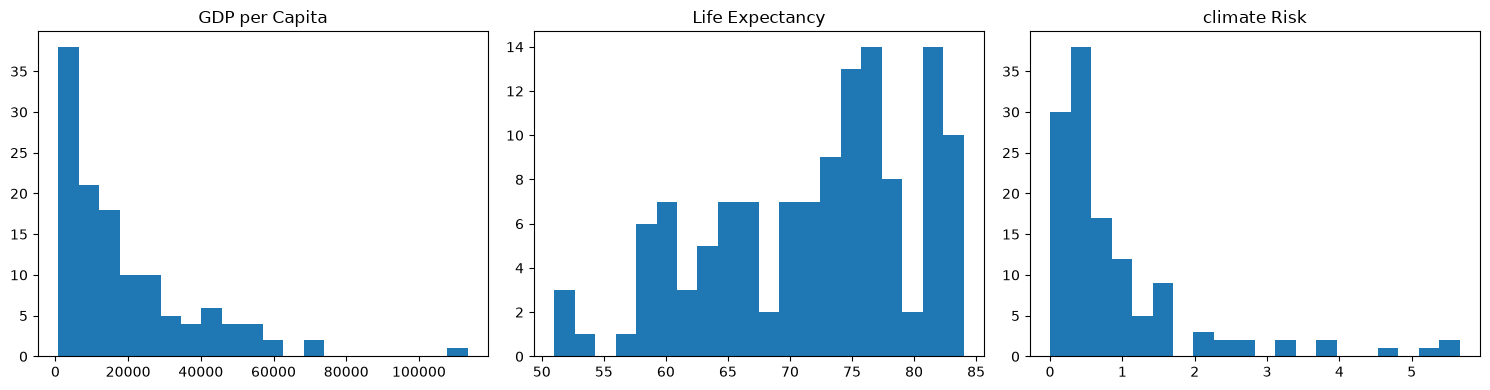

In [194]:
# histogram

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize = (15, 4))

axes[0].hist(merged_2016['gdp_per_capita'], bins = 20)
axes[0].set_title('GDP per Capita')

axes[1].hist(merged_2016['life_expectancy'], bins = 20)
axes[1].set_title('Life Expectancy')

axes[2].hist(merged_2016['climate_risk'], bins = 20)
axes[2].set_title('climate Risk')

plt.tight_layout()
plt.show()

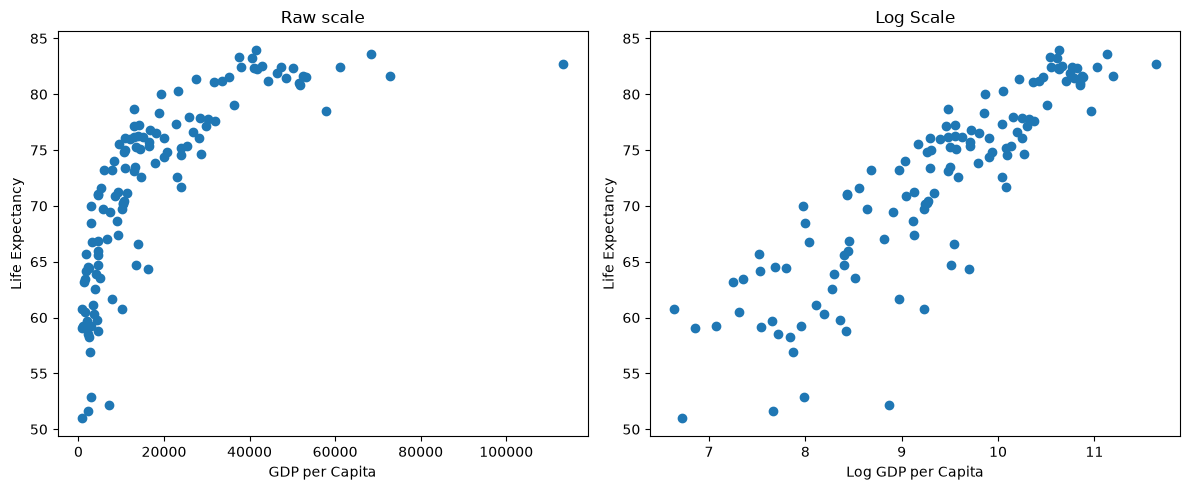

In [196]:
# log scale plot

import numpy as np
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].scatter(merged_2016['gdp_per_capita'], merged_2016['life_expectancy'])
axes[0].set_xlabel('GDP per Capita')
axes[0].set_ylabel('Life Expectancy')
axes[0].set_title('Raw scale')

axes[1].scatter(np.log(merged_2016['gdp_per_capita']), merged_2016['life_expectancy'])
axes[1].set_xlabel('Log GDP per Capita')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Log Scale')

plt.tight_layout()
plt.show()


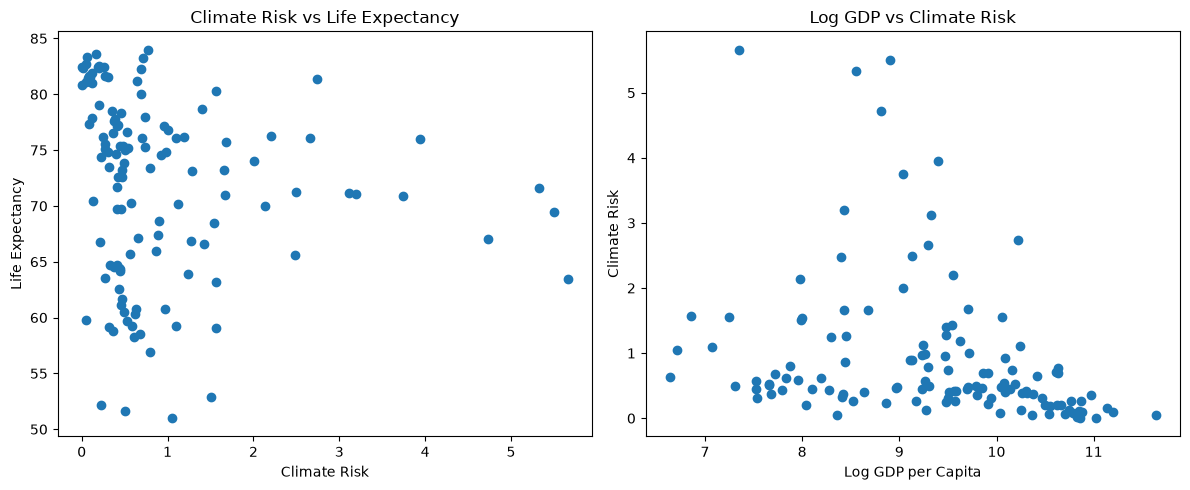

In [197]:
# climate view

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

axes[0].scatter(merged_2016['climate_risk'], merged_2016['life_expectancy'])
axes[0].set_xlabel('Climate Risk')
axes[0].set_ylabel('Life Expectancy')
axes[0].set_title('Climate Risk vs Life Expectancy')

axes[1].scatter(np.log(merged_2016['gdp_per_capita']), merged_2016['climate_risk'])
axes[1].set_xlabel('Log GDP per Capita')
axes[1].set_ylabel('Climate Risk')
axes[1].set_title('Log GDP vs Climate Risk')

plt.tight_layout()
plt.show()

In [198]:
# correlation matrix
merged_2016['log_gdp'] = np.log(merged_2016['gdp_per_capita'])
merged_2016[['log_gdp', 'life_expectancy', 'climate_risk']].corr()

,log_gdp,life_expectancy,climate_risk
log_gdp,1.000000,0.878693,-0.294411
life_expectancy,0.878693,1.000000,-0.143805
climate_risk,-0.294411,-0.143805,1.000000
